# China's Counter-Strike Scene: Tier-1/2 Trajectory and Shape, 2005-2026

**Purpose:** the "wait, China is #1 for grassroots CS tournament count?"
question from `research/esports_lifecycle_and_maturity/notebooks/grassroots_scene_comparison.ipynb` (confirmed real,
not a counting artifact -- see that notebook's own follow-up check) led
directly to this one: at the *competitive* (tier-1/2) level, how has
China's Counter-Strike scene actually grown and changed shape over time?
Extends `research/esports_lifecycle_and_maturity/brief.md`'s own CS trajectory
question down to one specific country, using the same tier-1/2 tournament
data `cs_growth_trajectory.ipynb` already established conventions for.

**Scope, stated up front**: this measures tournaments *hosted* in China --
not Chinese teams' results at tournaments hosted elsewhere (no
roster/participant data exists in this project's schema at all, PRD Sec19),
and not China's own audience/viewership (Twitch is not meaningfully
accessible in China, and PRD Sec9.8 already found no legitimate access path
to the Chinese platforms -- Douyu, Huya, Bilibili -- that would actually
carry that audience). This is a competitive-infrastructure story, not an
audience one.

In [1]:
import csv
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

from etl.db import get_connection

conn = get_connection()
plt.rcParams["figure.dpi"] = 110

deflator = {}
with open(REPO_ROOT / "data" / "reference" / "cpi_deflator.csv") as f:
    for row in csv.DictReader(f):
        deflator[int(row["year"])] = float(row["deflator_to_2025"])

TODAY = "2026-09-11"  # this notebook's own build date -- see Sec1 for why it matters

## 1. Data coverage

64 tier-1/2 (S-Tier/A-Tier) Counter-Strike tournaments have been hosted in
China since Liquipedia's earliest coverage (2005) through already-announced
2027 events. Built the same day as this notebook (2026-09-11), so 2026 is a
**partial year mixing already-happened and merely-announced events** --
handled explicitly below rather than let it silently inflate the most
recent bar. 2027 (one announced event, PGL/2027/China) is excluded from
every trend chart as too far out to be informative on its own.

In [2]:
china_rows = pd.read_sql_query(
    "SELECT liquipedia_page, start_date, prize_pool, currency, team_number "
    "FROM tournaments WHERE title_id='counter_strike' AND tier IN ('S-Tier','A-Tier') "
    "AND country='China' AND start_date IS NOT NULL ORDER BY start_date",
    conn,
)
print(f"{len(china_rows)} China tier-1/2 tournaments total")
print(f"Date range: {china_rows['start_date'].min()} to {china_rows['start_date'].max()}")

already_2026 = china_rows[(china_rows["start_date"] >= "2026") & (china_rows["start_date"] < TODAY)]
future_2026 = china_rows[(china_rows["start_date"] >= TODAY) & (china_rows["start_date"] < "2027")]
print(f"\n2026: {len(already_2026)} already happened, {len(future_2026)} still announced/future")
print("Future 2026 events:", future_2026["liquipedia_page"].tolist())

63 China tier-1/2 tournaments total
Date range: 2005-06-04 to 2027-04-16

2026: 5 already happened, 2 still announced/future
Future 2026 events: ['XSE Pro League/Season 9', 'Intel Extreme Masters/2026/Beijing']


## 2. Tournament count and prize money over time

Two eras of real activity, separated by two multi-year gaps -- not a
smooth trajectory.

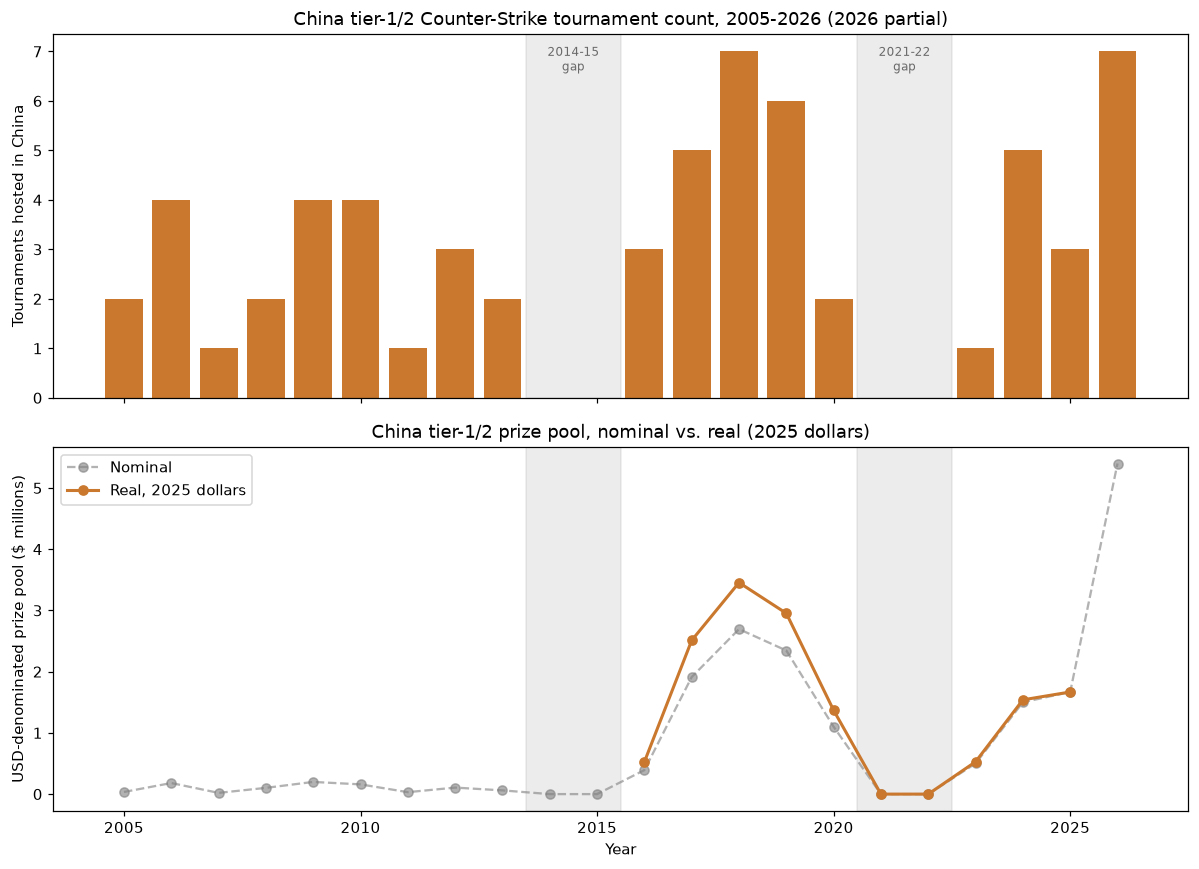

Year | tournaments | nominal USD | real 2025 USD
2005 |  2 | $    35,000 | $       nan
2006 |  4 | $   181,000 | $       nan
2007 |  1 | $    20,000 | $       nan
2008 |  2 | $   101,975 | $       nan
2009 |  4 | $   199,000 | $       nan
2010 |  4 | $   159,000 | $       nan
2011 |  1 | $    31,600 | $       nan
2012 |  3 | $   106,456 | $       nan
2013 |  2 | $    60,927 | $       nan
2014 |  0 | $         0 | $       nan
2015 |  0 | $         0 | $       nan
2016 |  3 | $   392,297 | $   526,228
2017 |  5 | $ 1,911,950 | $ 2,510,773
2018 |  7 | $ 2,695,000 | $ 3,454,990
2019 |  6 | $ 2,345,000 | $ 2,953,058
2020 |  2 | $ 1,100,000 | $ 1,368,290
2021 |  0 | $         0 | $         0
2022 |  0 | $         0 | $         0
2023 |  1 | $   500,000 | $   528,300
2024 |  5 | $ 1,500,000 | $ 1,539,600
2025 |  3 | $ 1,668,000 | $ 1,668,000
2026 |  7 | $ 5,400,000 | $       nan


In [3]:
yearly = china_rows.copy()
yearly["yr"] = yearly["start_date"].str.slice(0, 4)
yearly = yearly[(yearly["yr"] >= "2005") & (yearly["yr"] <= "2026")]

counts = yearly.groupby("yr").size().reindex([str(y) for y in range(2005, 2027)], fill_value=0)

usd = yearly[(yearly["prize_pool"].notna()) & ((yearly["currency"] == "USD") | (yearly["currency"].isna()))]
prize_by_yr = usd.groupby("yr")["prize_pool"].sum().reindex([str(y) for y in range(2005, 2027)], fill_value=0)
real_by_yr = pd.Series(
    {yr: v * deflator.get(int(yr), float("nan")) for yr, v in prize_by_yr.items()}
)

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
years_int = list(range(2005, 2027))

axes[0].bar(years_int, counts.values, color="#c9782e")
axes[0].axvspan(2013.5, 2015.5, color="gray", alpha=0.15)
axes[0].axvspan(2020.5, 2022.5, color="gray", alpha=0.15)
axes[0].text(2014.5, axes[0].get_ylim()[1]*0.9, "2014-15\ngap", ha="center", fontsize=8, color="dimgray")
axes[0].text(2021.5, axes[0].get_ylim()[1]*0.9, "2021-22\ngap", ha="center", fontsize=8, color="dimgray")
axes[0].set_ylabel("Tournaments hosted in China")
axes[0].set_title("China tier-1/2 Counter-Strike tournament count, 2005-2026 (2026 partial)")

axes[1].plot(years_int, prize_by_yr.values / 1e6, "o--", color="gray", alpha=0.6, label="Nominal")
axes[1].plot(years_int, real_by_yr.values / 1e6, "o-", color="#c9782e", linewidth=2, label="Real, 2025 dollars")
axes[1].axvspan(2013.5, 2015.5, color="gray", alpha=0.15)
axes[1].axvspan(2020.5, 2022.5, color="gray", alpha=0.15)
axes[1].set_ylabel("USD-denominated prize pool ($ millions)")
axes[1].set_xlabel("Year")
axes[1].set_title("China tier-1/2 prize pool, nominal vs. real (2025 dollars)")
axes[1].legend()

plt.tight_layout()
plt.savefig(Path.cwd() / "_china_cs_fig1_trend.png", dpi=110)
plt.show()

print("Year | tournaments | nominal USD | real 2025 USD")
for yr in [str(y) for y in range(2005, 2027)]:
    print(f"{yr} | {int(counts[yr]):2d} | ${prize_by_yr[yr]:>10,.0f} | ${real_by_yr[yr]:>10,.0f}")

**Read**: not a single trajectory but two distinct booms separated by
two real gaps. A modest founding era (2005-2013, $20K-$200K events, mostly
regional legs of global circuits -- WCG, IEM, WSVG) is followed by **zero
tournaments in 2014 and 2015**, then a sharp boom (2016-2020, peaking at
$3.45M real in 2018) driven by large domestically-funded events, then
**zero tournaments again in 2021 and 2022**, then a recovery that's
already produced 2026's **highest nominal total on record ($5.4M)** before
the year is even over -- CPI deflation isn't computable for 2026 yet
(`data/reference/cpi_deflator.csv`'s most recent year is 2025), so that
comparison is nominal-to-nominal for now, not apples-to-apples with the
real-dollar 2018 peak.

## 3. The two gaps, investigated

Neither gap is explained by a global industry-wide pause -- checked
directly rather than assumed.

In [4]:
global_counts = pd.read_sql_query(
    "SELECT substr(start_date,1,4) AS yr, count(*) AS n_global "
    "FROM tournaments WHERE title_id='counter_strike' AND tier IN ('S-Tier','A-Tier') "
    "AND start_date GLOB '[0-9][0-9][0-9][0-9]-*' AND start_date>='2013' AND start_date<'2024' "
    "GROUP BY yr ORDER BY yr",
    conn,
)
print("GLOBAL tier-1/2 CS tournament count (all countries), for comparison:")
print(global_counts.to_string(index=False))

GLOBAL tier-1/2 CS tournament count (all countries), for comparison:
  yr  n_global
2013        33
2014        34
2015        77
2016        73
2017        69
2018        79
2019        78
2020        78
2021        58
2022        43
2023        54


**2014-15 gap: China-specific, not global.** The global tier-1/2 count
was *rising* through this exact window (34 in 2014, then 77 in 2015 -- its
highest point in the whole 2013-2023 span shown above), while China had
zero events either year. This rules out a general "the whole scene paused"
explanation. The most plausible read, not independently confirmed here: this
is exactly the CS 1.6-to-CS:GO client transition period, and CS 1.6 had
historically been unusually entrenched in China's domestic scene relative to
the West -- a domestic adoption lag, not a global pause, would produce
precisely this pattern (China quiet while the rest of the world's CS:GO
scene was accelerating).

**2021-22 gap: real, sharper than the global trend, and with direct
supporting evidence.** Global tier-1/2 count declined too (58 in 2021, 43
in 2022 -- consistent with `research/esports_lifecycle_and_maturity/brief.md`'s own
2021-2023 trough finding), but never hit zero. China's did, for two full
years. Checked directly what happened to the dominant 2016-2020 organizer,
World Electronic Sports Games (WESG):

In [5]:
wesg = pd.read_sql_query(
    "SELECT liquipedia_page, country, start_date FROM tournaments "
    "WHERE title_id='counter_strike' AND liquipedia_page LIKE 'World Electronic Sports Games%' "
    "AND start_date >= '2020' ORDER BY start_date",
    conn,
)
print(f"WESG-branded pages globally, 2020 onward: {len(wesg)}")
print(wesg.to_string(index=False))
print("\nLast WESG activity anywhere in this dataset:", wesg["start_date"].max())

WESG-branded pages globally, 2020 onward: 24
                                                              liquipedia_page       country start_date
       World Electronic Sports Games/2019/Latin America/Brazil/Qualifier/Open        Brazil 2020-01-10
            World Electronic Sports Games/2019/Latin America/Brazil/Qualifier        Brazil 2020-01-12
                      World Electronic Sports Games/2019/Latin America/Mexico        Mexico 2020-01-18
                   World Electronic Sports Games/2019/Russia/Qualifier/Open/1        Russia 2020-02-01
                   World Electronic Sports Games/2019/Russia/Qualifier/Open/2        Russia 2020-02-04
                          World Electronic Sports Games/2019/Russia/Qualifier        Russia 2020-02-07
                      World Electronic Sports Games/2019/Female/Latin America        Brazil 2020-02-15
                             World Electronic Sports Games/2019/Latin America        Brazil 2020-02-15
                            

**A real, concrete data point, not just an absence**: WESG's "2021"
edition's regional qualifiers ran in Brazil and Latin America in
Jan-Feb 2021 -- the organizer was actively running events elsewhere in the
world at exactly this time -- but **no China-hosted grand final for the
2021 edition exists anywhere in this dataset**, and WESG never appears
again after February 2021. The qualifiers-ran-but-the-China-finals-never-
happened pattern is consistent with China's own COVID-zero border policy
(among the strictest and longest-lasting globally, holding through most of
2022 while much of the rest of the world had reopened) preventing WESG's
traditional China-hosted finals specifically, rather than WESG being
cancelled everywhere at once. Flagged as a plausible, well-supported read,
not an independently confirmed causal claim -- this project has no direct
source on WESG's own internal decision-making.

## 4. The shape has changed, not just the volume

Same tournament count doesn't mean the same scene. Grouping by organizer
(the tournament page's own top-level name) across the three eras:

In [6]:
def organizer(page):
    return page.split("/")[0]

for label, lo, hi in [
    ("2005-2013 (founding era)", "2005", "2014"),
    ("2016-2020 (WESG boom)", "2016", "2021"),
    ("2023-2027 (current revival)", "2023", "2028"),
]:
    era = china_rows[(china_rows["start_date"] >= lo) & (china_rows["start_date"] < hi)]
    orgs = era["liquipedia_page"].map(organizer).value_counts()
    top_share = orgs.iloc[0] / orgs.sum() if len(orgs) else float("nan")
    print(f"{label}: {len(era)} events, {len(orgs)} distinct organizers, "
          f"top organizer ({orgs.index[0]}) = {top_share:.0%} of events")
    print("  ", dict(orgs))
    print()

2005-2013 (founding era): 23 events, 12 distinct organizers, top organizer (Intel Extreme Masters) = 17% of events
   {'Intel Extreme Masters': np.int64(4), 'WEM': np.int64(3), 'K1 League': np.int64(3), 'WSVG': np.int64(2), 'IEF': np.int64(2), 'World Cyber Games': np.int64(2), 'MSI Beat IT': np.int64(2), 'ACON5': np.int64(1), 'China Korea Cyber Games': np.int64(1), 'WEG Masters 2006': np.int64(1), 'World eSports Festival': np.int64(1), 'KODE5': np.int64(1)}

2016-2020 (WESG boom): 23 events, 12 distinct organizers, top organizer (World Electronic Sports Games) = 30% of events
   {'World Electronic Sports Games': np.int64(7), 'EXTREMESLAND': np.int64(4), 'CS:GO Asia Championships': np.int64(2), 'Intel Extreme Masters': np.int64(2), 'International Gaming League': np.int64(1), 'World Cyber Arena': np.int64(1), 'Minor Championship': np.int64(1), 'StarLadder i-League': np.int64(1), 'China Top': np.int64(1), 'StarLadder ImbaTV': np.int64(1), 'Eastide': np.int64(1), 'StarSeries i-League': np.

**Read**: the 2016-2020 boom was structurally fragile in a way its
raw numbers didn't show -- World Electronic Sports Games alone ran 7 of 23
events (30%) and, more importantly, nearly all the *largest* prize pools
($890K-$1.5M each, versus $100K-$300K for everything else that era). When
that one organizer stopped, the scene didn't have a second pillar to fall
back on -- consistent with the sudden drop to zero in 2021. The current
revival looks structurally different: 7 distinct organizers across 17
events, no single one above 24% of the total, and critically, it includes
**global-tier organizers returning or arriving for the first time** --
Intel Extreme Masters (which last hosted in China in 2019) came back for
Chengdu in 2024 and 2025, and PGL's 2027 announcement is that organizer's
*first-ever* China event. A scene anchored by one big domestically-funded
event is structurally different from one drawing in multiple independent,
globally-established organizers -- more resilient in principle, though only
3-4 years old and not yet tested against a shock the way the WESG era was.

## 5. The 2024 Shanghai Major — a real institutional milestone

Perfect World/Major/2024/Shanghai is China's first-ever CS Major (the
highest tier of event Valve licenses) -- not a regional leg or qualifier,
the genuine flagship.

In [7]:
major = china_rows[china_rows["liquipedia_page"] == "Perfect World/Major/2024/Shanghai"]
print(major[["liquipedia_page", "start_date", "prize_pool", "currency", "team_number"]].to_string(index=False))

qualifiers = china_rows[china_rows["liquipedia_page"].str.startswith("Perfect World/Major/2024/Shanghai/")]
print(f"\n{len(qualifiers)} China-hosted regional qualifier legs fed into it:")
print(qualifiers[["liquipedia_page", "start_date"]].to_string(index=False))

                  liquipedia_page start_date  prize_pool currency  team_number
Perfect World/Major/2024/Shanghai 2024-11-30   1250000.0      USD         24.0

3 China-hosted regional qualifier legs fed into it:
                           liquipedia_page start_date
Perfect World/Major/2024/Shanghai/Americas 2024-11-12
Perfect World/Major/2024/Shanghai/Europe A 2024-11-17
Perfect World/Major/2024/Shanghai/Europe B 2024-11-21


A $1.25M flagship event with three separate China-hosted regional
qualifier legs feeding into it (Americas, Europe A, Europe B) -- China
wasn't just hosting a Major, it was hosting *qualifying infrastructure for
teams from other regions* to reach it, a meaningfully deeper level of
institutional trust/investment than simply hosting the finals alone.

## 6. State today: is 2026 really the best year on record?

Nominally, yes -- but that mixes already-happened and merely-announced
money. Split explicitly:

In [8]:
already = china_rows[(china_rows["start_date"] >= "2026") & (china_rows["start_date"] < TODAY)]
future = china_rows[(china_rows["start_date"] >= TODAY) & (china_rows["start_date"] < "2027")]

already_usd = already[(already["prize_pool"].notna()) & ((already["currency"] == "USD") | (already["currency"].isna()))]["prize_pool"].sum()
future_usd = future[(future["prize_pool"].notna()) & ((future["currency"] == "USD") | (future["currency"].isna()))]["prize_pool"].sum()

print(f"2026 already happened (through {TODAY}): {len(already)} events, ${already_usd:,.0f} USD")
print(f"2026 still announced/future: {len(future)} events, ${future_usd:,.0f} USD")
print(f"\nFor comparison, prior nominal-total record year: "
      f"2018 (${prize_by_yr['2018']:,.0f}), 2017 (${prize_by_yr['2017']:,.0f})")
print(f"\nAlready-realized 2026 total alone (${already_usd:,.0f}) "
      f"{'exceeds' if already_usd > prize_by_yr['2018'] else 'does not exceed'} "
      f"every prior year's FULL-YEAR nominal total.")

2026 already happened (through 2026-09-11): 5 events, $4,150,000 USD
2026 still announced/future: 2 events, $1,250,000 USD

For comparison, prior nominal-total record year: 2018 ($2,695,000), 2017 ($1,911,950)

Already-realized 2026 total alone ($4,150,000) exceeds every prior year's FULL-YEAR nominal total.


**Confirmed, conservatively**: even counting only events that have
already happened (excluding the announced-but-not-yet-run October CNY
event and the $1.25M November IEM Beijing), 2026 already exceeds every
prior full year's nominal total on record. This isn't a projection or an
artifact of counting future-announced money -- it's already true from
realized events alone, with a quarter of the year and one confirmed
major event (IEM Beijing) still to come.

## 7. What this notebook can't tell you

Stated plainly, not buried in a footnote: this measures **where
tournaments are hosted**, not **audience size** or **Chinese team
success**. Twitch itself is not meaningfully accessible within China, so
this project's own live-viewership data says nothing about Chinese
audience engagement with these events (or with Counter-Strike generally)
-- PRD §9.8 already investigated the platforms that would actually carry
that audience (Douyu, Huya, Bilibili) and found no legitimate access path,
only third-party aggregate reports from firms like Niko Partners or
Streams Charts, which this project doesn't currently ingest. Separately,
there's no roster/participant data anywhere in this project's schema (PRD
§19's still-unbuilt player/roster connector), so this notebook can't say
whether Chinese *teams* are becoming more competitive globally -- only
that China is hosting more, and more diverse, tier-1/2 events.

## 8. Bottom line

China's competitive Counter-Strike infrastructure has grown through two
distinct booms separated by two real, multi-year collapses to zero — not
a smooth trajectory, and the shape of each boom is different. The
2016-2020 boom was carried disproportionately by one domestically-funded
mega-event (WESG); when that organizer folded (evidenced directly: its
last activity anywhere in this dataset is February 2021, with 2021
qualifiers run elsewhere in the world but no China-hosted finals ever
recorded), China's tier-1/2 hosting went to zero for two full years — a
sharper, more complete collapse than the broader global 2021-2023 trough
this project's own tier-1/2 data already shows, plausibly (not
independently confirmed) tied to China's unusually strict and
long-lasting COVID-era border policy. The current revival (2023 onward)
looks structurally healthier: more organizers, none dominant, and —
concretely — global-tier organizers (Intel Extreme Masters, PGL) choosing
to return or arrive for the first time, culminating in China's first-ever
Major (Shanghai, 2024, complete with its own regional qualifier
infrastructure) and a 2026 that has already, on realized events alone,
become the biggest year on record. Whether this more diversified shape
proves more durable than the WESG era's single-pillar model is a real
open question this data can't yet answer — it's three years old against
a boom-bust cycle that took roughly five years to complete last time.